In [1]:
import numpy as np
import pandas as pd

data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

df = pd.read_csv(data)

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

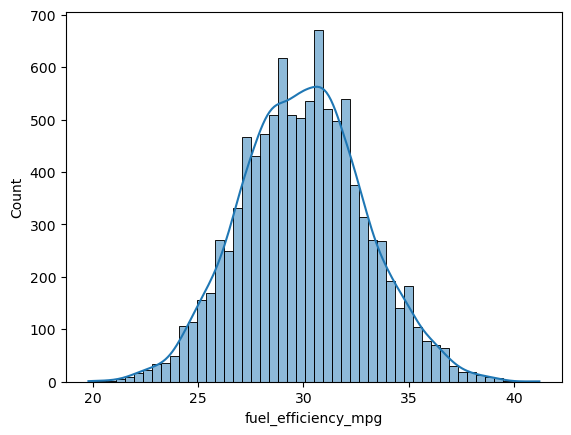

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data = df['fuel_efficiency_mpg'], bins = 50, kde = True)

# q -1

In [6]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

# q-2

In [7]:
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


# q-3

In [8]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [9]:
df_train_0 = df_train.copy()
df_train_mean = df_train.copy()

df_val_0 = df_val.copy()
df_val_mean = df_val.copy()

df_train_0['horsepower'] = df_train['horsepower'].fillna(0)
df_train_mean['horsepower'] = df_train['horsepower'].fillna(df_train['horsepower'].mean())

In [13]:
'''
'engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg'
'''

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB
